# Libraries

In [ ]:
import healpy as hp
import numpy as np
import matplotlib.pyplot as plt
import cobaya as cby
#from mpi4py import MPI, __version__
import pandas as pd
%matplotlib inline
from astropy.io import fits

#print(__version__ if MPI.COMM_WORLD.Get_rank() else '')
import camb

import matplotlib.colors as colors

# Experimental Data

## Data from Planck Legacy Archive

In [ ]:



unbin_cl = pd.read_csv('maps/COM_PowerSpect_CMB-TT-full_R3.01.txt', sep=',')

unbin_cl.head()

unbin_cl.columns = ['ell', 'D_ell', '-dD_ell', '+dD_ell']

unbin_cl.head()

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

ell = unbin_cl['ell']
D_ell = unbin_cl['D_ell']
errors = (unbin_cl['-dD_ell'],unbin_cl['+dD_ell'])

# Create a figure and grid for subplots
fig, (ax1, ax2) = plt.subplots(2, 1, sharex=True, gridspec_kw={'height_ratios': [3, 1]})
fig.subplots_adjust(hspace=0)
fig.set_size_inches(15,10)
# Top subplot
ax1.errorbar(ell, D_ell, yerr=errors, fmt='o', color='red', ecolor='blue', elinewidth=1, capsize=2, markersize=2)
ax1.set_ylabel('$D_\ell^{TT} \, [\mu K^2]$')
ax1.grid(True, which='both', linestyle='--', linewidth=0.5)

# Bottom subplot (Residuals)
delta_D_ell = np.array(D_ell[:-1]) - np.array(D_ell[1:])

#ax2.errorbar(ell, delta_D_ell, yerr=errors, fmt='o', color='red', ecolor='blue', elinewidth=1, capsize=2, markersize=2)
ax2.set_ylabel('$\Delta D_\ell^{TT}$')
ax2.set_xlabel('$\ell$')
ax2.grid(True, which='both', linestyle='--', linewidth=0.5)
ax1.title.set_text("Power Spectrum of TT from Planck Archive Unbinned")
ax1.axvline(x=20, color='black', linestyle='--', linewidth=0.5)
ax2.axvline(x=20, color='black', linestyle='--', linewidth=0.5)
# Show plot
plt.xscale('log')
plt.yscale('linear')
plt.show()



In [ ]:

bin_cl = pd.read_csv('maps/COM_PowerSpect_CMB-TT-binned_R3.01.txt', sep=',')

bin_cl.head()

bin_cl.columns = ['ell', 'D_ell', '-dD_ell', '+dD_ell','BestFit']

bin_cl.head()

In [ ]:
ell = bin_cl['ell']
D_ell = bin_cl['D_ell']
errors = (bin_cl['-dD_ell'],bin_cl['+dD_ell'])

# Create a figure and grid for subplots
fig, (ax1, ax2) = plt.subplots(2, 1, sharex=True, gridspec_kw={'height_ratios': [3, 1]})
fig.subplots_adjust(hspace=0)
fig.set_size_inches(15,10)
# Top subplot
ax1.errorbar(ell, D_ell, yerr=errors, fmt='o', color='red', ecolor='blue', elinewidth=1, capsize=2, markersize=2, label='Data')
ax1.plot(ell, bin_cl['BestFit'], color='black', label='Best Fit')
ax1.set_ylabel('$D_\ell^{TT} \, [\mu K^2]$')
ax1.grid(True, which='both', linestyle='--', linewidth=0.5)
ax1.legend(loc='upper right')
# Bottom subplot (Residuals)
delta_D_ell = np.array(D_ell) - np.array(bin_cl['BestFit'])

ax2.errorbar(ell, delta_D_ell, yerr=errors, fmt='o', color='red', ecolor='blue', elinewidth=1, capsize=2, markersize=2)
ax2.set_ylabel('$\Delta D_\ell^{TT}$')
ax2.set_xlabel('$\ell$')
ax2.grid(True, which='both', linestyle='--', linewidth=0.5)
ax1.title.set_text("Power Spectrum of TT from Planck Archive Binned")
ax1.axvline(x=20, color='black', linestyle='--', linewidth=0.5)
ax2.axvline(x=20, color='black', linestyle='--', linewidth=0.5)
# Show plot
plt.xscale('log')
plt.yscale('linear')
plt.show()

In [ ]:
def clcorr(cls, c= False):
    import camb.correlations

    if c:
        xvals = np.linspace(-0.999,0.999,1000)
        theta=np.arccos(xvals)*180/np.pi

        corrs = camb.correlations.cl2corr(cls,xvals)
        return corrs[:,0], theta
    else:
        clstot = np.tile(np.array(cls).reshape(-1, 1), 4)
        xvals = np.linspace(-0.999,0.999,1000)
        theta=np.arccos(xvals)*180/np.pi

        corrs = camb.correlations.cl2corr(clstot,xvals)
        return corrs[:,0], theta

### Comparativa entre los datos y el best fit the planck

### Comparativa entre los parámetros de mejor ajuste con el mejor ajuste de Planck

### Comparativa entre los datos de planck y los parámetros del mejor ajuste de planck

In [ ]:



def solidang(cor,theta):
    from scipy.integrate import simpson


    # Calcular sin(theta)
    sin_theta = np.sin(theta)

    integrand = cor * sin_theta

    # Integrar usando la regla del trapecio
    integral = simpson(integrand, theta)

    # Multiplicar por 2*pi para obtener la integral sobre el ángulo sólido
    integral_solido = 2 * np.pi * integral

    return round(integral_solido,3)


def clcorrcamb(cls, c= False):
    import camb.correlations
    xvals = np.linspace(-0.999,0.999,1000)
    theta=np.arccos(xvals)*180/np.pi
    if c:
        

        corrs = camb.correlations.cl2corr(cls,xvals)
        inte= solidang(corrs[:,0],theta)
        return corrs[:,0], theta, inte
    else:
        clstot = np.tile(np.array(cls).reshape(-1, 1), 4)

        corrs = camb.correlations.cl2corr(clstot,xvals)
        inte= solidang(corrs[:,0], theta)
        return corrs[:,0], theta, inte

def clcorr(dls, c= False):
    
    from scipy.special import eval_legendre
    xvals = np.linspace(-0.999,0.999,1000)
    theta=np.arccos(xvals)*180/np.pi
    
    if c:
        cls=dls[:,0]
        lmax=len(cls)
        corr= np.zeros(dtype=np.float64, shape=xvals.shape)
        ell = np.linspace(2,lmax+2,lmax)
        cl=cls*2*np.pi*1/(ell*(ell+1))
        for i ,j in enumerate(cl):
            deg=i+2
            P_n = eval_legendre(deg, xvals)
            corr += (2*deg+1)*j*P_n
        corrs = 1/(4*np.pi)*corr
        inte= solidang(corrs,theta)
        return corrs, theta, inte
    else:
        cls=dls
        lmax=len(cls)
        corr= np.zeros(dtype=np.float64, shape=xvals.shape)
        ell = np.linspace(2,lmax+2,lmax)
        cl=cls*2*np.pi*1/(ell*(ell+1))
        for i ,j in enumerate(cl):
            deg=i+2
            P_n = eval_legendre(deg, xvals)
            corr += (2*deg+1)*j*P_n
        corrs = 1/(4*np.pi)*corr
        inte= solidang(corrs, theta)
        return corrs, theta, inte

def clandcorrplotbase(file, expdata=unbin_cl):
    from scipy.stats import chisquare
    data = pd.read_csv(f'COM_CosmoParams_fullGrid_R3.01/base/{file}/base_{file}.minimum.theory_cl', sep=r'\s+', skiprows=1, header=None)
    data.columns = ["L", "TT", "TE", "EE", "BB", "PP"]
    #print(data.head())

    # Define the list of parameter names to keep
    params_to_keep = {"omegabh2", "omegach2", "H0", "tau", "omegak", "logA", "ns", 
                    "mnu", "w", "wa", "nnu", "yhe", "Alens", "nrun"}

    # Read the file while skipping LaTeX notation at the end
    df = pd.read_csv(f'COM_CosmoParams_fullGrid_R3.01/base/{file}/base_{file}.minimum', sep=r"\s+", header=None, usecols=[1, 2], names=["value", "param"])

    # Filter rows where the 'param' column matches the parameters we want
    df_filtered = df[df["param"].isin(params_to_keep)]

    # Display the filtered dataframe
    df_filtered['value']=df_filtered['value'].astype(float)

    dic = {}
    for i, j in zip(df_filtered['param'],df_filtered['value']):
        dic[i]= j
    #print(dic)

    pars = camb.set_params(ombh2=dic['omegabh2'], omch2=dic['omegach2'], H0 = dic['H0'],omk=dic['omegak'],
                            YHe=dic['yhe'], nnu=dic['nnu'], nrun=dic['nrun'], Alens=dic['Alens'], ns=dic['ns'], As=np.exp(dic['logA'])*1e-10,w=dic['w'],wa=dic['wa'], mnu=dic['mnu'], tau=dic['tau'])
    #res = camb.get_background(pars, no_thermo=True)
    resu = camb.get_results(pars)
    cls = resu.get_cmb_power_spectra(pars, CMB_unit='muK',lmax=max(data['L']))
    totCL=cls['total']

    ell = expdata['ell'][:len(data['L'])]
    D_ell = expdata['D_ell'][:len(data['L'])]
    errors = (expdata['-dD_ell'][:len(data['L'])],expdata['+dD_ell'][:len(data['L'])])
    fig, axes = plt.subplots(6, 2, sharex='col', gridspec_kw={'height_ratios': [3, 1,3, 1,3, 1]})
    fig.subplots_adjust(hspace=0)
    fig.set_size_inches(60,15)
    # Experimental vs theory cl

    expected_th = data['TT'] * (D_ell.sum() / data['TT'].sum())
    
    mask = expected_th != 0
    D_ell_filtered = D_ell[mask]
    expected_th_filtered = expected_th[mask]

    # Normalize expected values to match observed values' sum
    expected_th_filtered *= D_ell_filtered.sum() / expected_th_filtered.sum()

    # Compute chi-square
    chi_th, _ = chisquare(D_ell_filtered, expected_th_filtered)
    axes[0,0].scatter(ell,data['TT'], marker="+", c='black', s=5, label='Best fit')
    axes[0,0].errorbar(ell, D_ell, yerr=errors, fmt='o', color='red', ecolor=colors.to_rgba('blue',0.2), elinewidth=1, capsize=2, markersize=2, label=rf"Planck data $\chi_n^2={round(chi_th,3)/len(D_ell[mask])}$")
    axes[0,0].set_ylabel(r'$D_\ell^{TT} \, [\mu K^2]$')

    # Bottom subplot (Residuals)
    delta_D_ell = np.array(D_ell) - np.array(data['TT'])

    axes[1,0].errorbar(data['L'], delta_D_ell, yerr=errors, fmt='o', color='green', ecolor=colors.to_rgba('blue',0.2), elinewidth=1, capsize=2, markersize=2, label="Residuals")
    axes[1,0].set_ylabel(r'$\Delta D_\ell^{TT}$')
    
    axes[0,0].title.set_text("Power Spectrum of TT from Planck Archive Unbinned")

    tcor, theta   ,_= clcorr(data['TT'] )
    expcor, theta ,_ = clcorr(D_ell )

    axes[0,1].scatter(theta,tcor, marker="+", c='black', s=2, label='Derived from best fit')
    axes[0,1].scatter(theta,expcor, marker="o", c='red', s=2, label='Derived from Planck data')
    axes[0,1].title.set_text("Correlation function")
    delta_corr=np.array(expcor) - np.array(tcor)
    axes[1,1].scatter(theta,delta_corr,marker="^", c='green', s=2, label="Residuals")
    axes[1,1].set_ylabel(r'$\Delta \xi (\theta)$')
    axes[0,1].set_ylabel(r'$\xi (\theta)$')

    # Theory vs CAMb

    axes[2,0].scatter(ell,data['TT'], marker="+", c='black', s=5, label='Best fit')
    axes[2,0].scatter(ell,totCL[:,0][2:], marker="o", c='red', s=5, label='CAMB results')
    axes[2,0].set_ylabel(r'$D_\ell^{TT} \, [\mu K^2]$')

    # Bottom subplot (Residuals)
    delta_D_ell = np.array(totCL[:,0][2:]) - np.array(data['TT'])

    axes[3,0].errorbar(data['L'], delta_D_ell, yerr=errors, fmt='o', color='green', ecolor=colors.to_rgba('blue',0.2), elinewidth=1, capsize=2, markersize=2, label="Residuals")
    axes[3,0].set_ylabel(r'$\Delta D_\ell^{TT}$')
    axes[3,0].set_xlabel(r'$\ell$')

    tcor, theta   , inte_bf= clcorr(data['TT'] )
    cambcor, theta, inte_camb = clcorr(totCL,True )

    axes[2,1].scatter(theta,tcor, marker="+", c='black', s=2, label='Derived from best fit')
    axes[2,1].scatter(theta,cambcor, marker="o", c='red', s=2, label='Derived from CAMB')
    delta_corr=np.array(cambcor) - np.array(tcor)
    axes[3,1].scatter(theta,delta_corr,marker="^", c='green', s=2, label="Residuals")
    axes[3,1].set_ylabel(r'$\Delta \xi (\theta)$')
    axes[2,1].set_ylabel(r'$\xi (\theta)$')

    # CAMB vs experimental
    expected_camb = totCL[:,0][2:] * (D_ell.sum() / totCL[:,0][2:].sum())

    # Apply mask
    mask2 = expected_camb != 0
    D_ell_filtered = D_ell[mask2]
    expected_camb_filtered = expected_camb[mask2]

    # Normalize expected values to match observed values' sum
    expected_camb_filtered *= D_ell_filtered.sum() / expected_camb_filtered.sum()

    # Compute chi-square
    chi_camb, _ = chisquare(D_ell_filtered, expected_camb_filtered)

    print(f"Excluding {len(D_ell)-len(D_ell[mask])} data points")
    print(f"Excluding {len(D_ell)-len(D_ell[mask2])} data points")
    
    axes[4,0].scatter(ell,totCL[:,0][2:], marker="o", c='black', s=5, label='CAMB results')
    axes[4,0].errorbar(ell, D_ell, yerr=errors, fmt='o', color='red', ecolor=colors.to_rgba('blue',0.2), elinewidth=1, capsize=2, markersize=2, label=rf"Planck data $\chi_n^2={round(chi_camb,3)/len(D_ell[mask2])}$")
    axes[4,0].set_ylabel(r'$D_\ell^{TT} \, [\mu K^2]$')

    # Bottom subplot (Residuals)
    delta_D_ell = np.array(D_ell) - np.array(totCL[:,0][2:])

    axes[5,0].errorbar(data['L'], delta_D_ell, yerr=errors, fmt='o', color='green', ecolor=colors.to_rgba('blue',0.2), elinewidth=1, capsize=2, markersize=2, label="Residuals")
    axes[5,0].set_ylabel(r'$\Delta D_\ell^{TT}$')
    axes[5,0].set_xlabel(r'$\ell$')

    expcor, theta , inte_exp = clcorr(D_ell )
    cambcor, theta,_ = clcorr(totCL,True )

    axes[4,1].scatter(theta,expcor, marker="+", c='red', s=2, label='Derived from Plancks Data')
    axes[4,1].scatter(theta,cambcor, marker="o", c='black', s=2, label='Derived from CAMB')
    delta_corr=np.array(expcor) - np.array(cambcor)
    axes[5,1].scatter(theta,delta_corr,marker="^", c='green', s=2, label="Residuals")
    axes[5,1].set_xlabel(r'$\theta [^\circ]$')
    axes[5,1].set_ylabel(r'$\Delta \xi (\theta)$')
    axes[4,1].set_ylabel(r'$\xi (\theta)$')
    fig.text(0.51, 0.82, "Experimenatl VS Bestfit\n" + r"$\int \xi(\theta)_{exp}d\Omega =$" + f"{inte_exp}", 
         ha='center', fontsize=12, fontweight='bold')

    fig.text(0.51, 0.52, "CAMB Best VS Bestfit\n" + r"$\int \xi(\theta)_{bf}d\Omega =$" + f"{inte_bf}", 
            ha='center', fontsize=12, fontweight='bold')

    fig.text(0.51, 0.22, "Experimenatl VS CAMB Best\n" + r"$\int \xi(\theta)_{CAMB}d\Omega =$" + f"{inte_camb}", 
            ha='center', fontsize=12, fontweight='bold')

    title = f"Comparision of plancks result for the chain {file}\n"
    for i in params_to_keep:
        title+=f"{i}: {dic[i]}  "
    fig.suptitle(title)

    for ax in axes[:,0]:
        ax.axvline(x=20, color='black', linestyle='--', linewidth=0.5)
        ax.set_yscale('linear')
        ax.grid(True, which='both', linestyle='--', linewidth=0.5)
        ax.legend(loc='upper right')
        ax.set_xscale('log')
    for ax in axes[:,1]:
        ax.set_xscale('linear')
        ax.set_xlim(0,max(theta)+0.5)
        ax.set_yscale('linear')
        ax.grid(True, which='both', linestyle='--', linewidth=0.5)
        ax.legend(loc='upper right')
    plt.legend()
    plt.savefig(f"Comp_Graphs/base/{file}.png")
    plt.close()

def clandcorrplotomega_k(file, expdata=unbin_cl):
    from scipy.stats import chisquare
    data = pd.read_csv(f'COM_CosmoParams_fullGrid_R3.01/base_omegak/{file}/base_omegak_{file}.minimum.theory_cl', sep=r'\s+', skiprows=1, header=None)
    data.columns = ["L", "TT", "TE", "EE", "BB", "PP"]
    #print(data.head())

    # Define the list of parameter names to keep
    params_to_keep = {"omegabh2", "omegach2", "H0", "tau", "omegak", "logA", "ns", 
                    "mnu", "w", "wa", "nnu", "yhe", "Alens", "nrun"}

    # Read the file while skipping LaTeX notation at the end
    df = pd.read_csv(f'COM_CosmoParams_fullGrid_R3.01/base_omegak/{file}/base_omegak_{file}.minimum', sep=r"\s+", header=None, usecols=[1, 2], names=["value", "param"])

    # Filter rows where the 'param' column matches the parameters we want
    df_filtered = df[df["param"].isin(params_to_keep)]

    # Display the filtered dataframe
    df_filtered['value']=df_filtered['value'].astype(float)

    dic = {}
    for i, j in zip(df_filtered['param'],df_filtered['value']):
        dic[i]= j
    #print(dic)

    pars = camb.set_params(ombh2=dic['omegabh2'], omch2=dic['omegach2'], H0 = dic['H0'],omk=dic['omegak'],
                            YHe=dic['yhe'], nnu=dic['nnu'], nrun=dic['nrun'], Alens=dic['Alens'], ns=dic['ns'], As=np.exp(dic['logA'])*1e-10,w=dic['w'],wa=dic['wa'], mnu=dic['mnu'], tau=dic['tau'])
    #res = camb.get_background(pars, no_thermo=True)
    resu = camb.get_results(pars)
    cls = resu.get_cmb_power_spectra(pars, CMB_unit='muK',lmax=max(data['L']))
    totCL=cls['total']

    ell = expdata['ell'][:len(data['L'])]
    D_ell = expdata['D_ell'][:len(data['L'])]
    errors = (expdata['-dD_ell'][:len(data['L'])],expdata['+dD_ell'][:len(data['L'])])
    fig, axes = plt.subplots(6, 2, sharex='col', gridspec_kw={'height_ratios': [3, 1,3, 1,3, 1]})
    fig.subplots_adjust(hspace=0)
    fig.set_size_inches(60,15)
    # Experimental vs theory cl

    expected_th = data['TT'] * (D_ell.sum() / data['TT'].sum())
    
    mask = expected_th != 0
    D_ell_filtered = D_ell[mask]
    expected_th_filtered = expected_th[mask]

    # Normalize expected values to match observed values' sum
    expected_th_filtered *= D_ell_filtered.sum() / expected_th_filtered.sum()

    # Compute chi-square
    chi_th, _ = chisquare(D_ell_filtered, expected_th_filtered)
    axes[0,0].scatter(ell,data['TT'], marker="+", c='black', s=5, label='Best fit')
    axes[0,0].errorbar(ell, D_ell, yerr=errors, fmt='o', color='red', ecolor=colors.to_rgba('blue',0.2), elinewidth=1, capsize=2, markersize=2, label=rf"Planck data $\chi_n^2={round(chi_th,3)/len(D_ell[mask])}$")
    axes[0,0].set_ylabel(r'$D_\ell^{TT} \, [\mu K^2]$')

    # Bottom subplot (Residuals)
    delta_D_ell = np.array(D_ell) - np.array(data['TT'])

    axes[1,0].errorbar(data['L'], delta_D_ell, yerr=errors, fmt='o', color='green', ecolor=colors.to_rgba('blue',0.2), elinewidth=1, capsize=2, markersize=2, label="Residuals")
    axes[1,0].set_ylabel(r'$\Delta D_\ell^{TT}$')
    
    axes[0,0].title.set_text("Power Spectrum of TT from Planck Archive Unbinned")

    tcor, theta   ,_= clcorr(data['TT'] )
    expcor, theta ,_ = clcorr(D_ell )

    axes[0,1].scatter(theta,tcor, marker="+", c='black', s=2, label='Derived from best fit')
    axes[0,1].scatter(theta,expcor, marker="o", c='red', s=2, label='Derived from Planck data')
    axes[0,1].title.set_text("Correlation function")
    delta_corr=np.array(expcor) - np.array(tcor)
    axes[1,1].scatter(theta,delta_corr,marker="^", c='green', s=2, label="Residuals")
    axes[1,1].set_ylabel(r'$\Delta \xi (\theta)$')
    axes[0,1].set_ylabel(r'$\xi (\theta)$')

    # Theory vs CAMb

    axes[2,0].scatter(ell,data['TT'], marker="+", c='black', s=5, label='Best fit')
    axes[2,0].scatter(ell,totCL[:,0][2:], marker="o", c='red', s=5, label='CAMB results')
    axes[2,0].set_ylabel(r'$D_\ell^{TT} \, [\mu K^2]$')

    # Bottom subplot (Residuals)
    delta_D_ell = np.array(totCL[:,0][2:]) - np.array(data['TT'])

    axes[3,0].errorbar(data['L'], delta_D_ell, yerr=errors, fmt='o', color='green', ecolor=colors.to_rgba('blue',0.2), elinewidth=1, capsize=2, markersize=2, label="Residuals")
    axes[3,0].set_ylabel(r'$\Delta D_\ell^{TT}$')
    axes[3,0].set_xlabel(r'$\ell$')

    tcor, theta   , inte_bf= clcorr(data['TT'] )
    cambcor, theta, inte_camb = clcorr(totCL,True )

    axes[2,1].scatter(theta,tcor, marker="+", c='black', s=2, label='Derived from best fit')
    axes[2,1].scatter(theta,cambcor, marker="o", c='red', s=2, label='Derived from CAMB')
    delta_corr=np.array(cambcor) - np.array(tcor)
    axes[3,1].scatter(theta,delta_corr,marker="^", c='green', s=2, label="Residuals")
    axes[3,1].set_ylabel(r'$\Delta \xi (\theta)$')
    axes[2,1].set_ylabel(r'$\xi (\theta)$')

    # CAMB vs experimental
    expected_camb = totCL[:,0][2:] * (D_ell.sum() / totCL[:,0][2:].sum())

    # Apply mask
    mask2 = expected_camb != 0
    D_ell_filtered = D_ell[mask2]
    expected_camb_filtered = expected_camb[mask2]

    # Normalize expected values to match observed values' sum
    expected_camb_filtered *= D_ell_filtered.sum() / expected_camb_filtered.sum()

    # Compute chi-square
    chi_camb, _ = chisquare(D_ell_filtered, expected_camb_filtered)
    print(f"Excluding {len(D_ell)-len(D_ell[mask])} data points")
    print(f"Excluding {len(D_ell)-len(D_ell[mask2])} data points")

    axes[4,0].scatter(ell,totCL[:,0][2:], marker="o", c='black', s=5, label='CAMB results')
    axes[4,0].errorbar(ell, D_ell, yerr=errors, fmt='o', color='red', ecolor=colors.to_rgba('blue',0.2), elinewidth=1, capsize=2, markersize=2, label=rf"Planck data $\chi_n^2={round(chi_camb,3)/len(D_ell[mask2])}$")
    axes[4,0].set_ylabel(r'$D_\ell^{TT} \, [\mu K^2]$')

    # Bottom subplot (Residuals)
    delta_D_ell = np.array(D_ell) - np.array(totCL[:,0][2:])

    axes[5,0].errorbar(data['L'], delta_D_ell, yerr=errors, fmt='o', color='green', ecolor=colors.to_rgba('blue',0.2), elinewidth=1, capsize=2, markersize=2, label="Residuals")
    axes[5,0].set_ylabel(r'$\Delta D_\ell^{TT}$')
    axes[5,0].set_xlabel(r'$\ell$')

    expcor, theta , inte_exp = clcorr(D_ell )
    cambcor, theta,_ = clcorr(totCL,True )

    axes[4,1].scatter(theta,expcor, marker="+", c='red', s=2, label='Derived from Plancks Data')
    axes[4,1].scatter(theta,cambcor, marker="o", c='black', s=2, label='Derived from CAMB')
    delta_corr=np.array(expcor) - np.array(cambcor)
    axes[5,1].scatter(theta,delta_corr,marker="^", c='green', s=2, label="Residuals")
    axes[5,1].set_xlabel(r'$\theta [^\circ]$')
    axes[5,1].set_ylabel(r'$\Delta \xi (\theta)$')
    axes[4,1].set_ylabel(r'$\xi (\theta)$')
    fig.text(0.51, 0.82, "Experimenatl VS Bestfit\n" + r"$\int \xi(\theta)_{exp}d\Omega =$" + f"{inte_exp}", 
         ha='center', fontsize=12, fontweight='bold')

    fig.text(0.51, 0.52, "CAMB Best VS Bestfit\n" + r"$\int \xi(\theta)_{bf}d\Omega =$" + f"{inte_bf}", 
            ha='center', fontsize=12, fontweight='bold')

    fig.text(0.51, 0.22, "Experimenatl VS CAMB Best\n" + r"$\int \xi(\theta)_{CAMB}d\Omega =$" + f"{inte_camb}", 
            ha='center', fontsize=12, fontweight='bold')

    title = f"Comparision of plancks result for the chain {file}\n"
    for i in params_to_keep:
        title+=f"{i}: {dic[i]}  "
    fig.suptitle(title)

    for ax in axes[:,0]:
        ax.axvline(x=20, color='black', linestyle='--', linewidth=0.5)
        ax.set_yscale('linear')
        ax.grid(True, which='both', linestyle='--', linewidth=0.5)
        ax.legend(loc='upper right')
        ax.set_xscale('log')
    for ax in axes[:,1]:
        ax.set_xscale('linear')
        ax.set_xlim(0,max(theta)+0.5)
        ax.set_yscale('linear')
        ax.grid(True, which='both', linestyle='--', linewidth=0.5)
        ax.legend(loc='upper right')
    plt.legend()
    plt.savefig(f"Comp_Graphs/Omega_k/{file}.png")
    plt.close()


In [ ]:
omegak = [
    "CamSpecHM_TT_lowl_lowE",
    "CamSpecHM_TT_lowl_lowE_BAO",
    "CamSpecHM_TT_lowl_lowE_lensing",
    "CamSpecHM_TTTEEE_lowl_lowE",
    "CamSpecHM_TTTEEE_lowl_lowE_BAO",
    "CamSpecHM_TTTEEE_lowl_lowE_lensing",
    "CleanedCamSpecHM_TT_lowl_lowE",
    "plikHM_TT_lowl_lowE",
    "plikHM_TT_lowl_lowE_BAO",
    "plikHM_TT_lowl_lowE_lensing",
    "plikHM_TTTEEE_lowl_lowE",
    "plikHM_TTTEEE_lowl_lowE_BAO",
    "plikHM_TTTEEE_lowl_lowE_lensing"
]
base = [
    "CamSpecHM_TT",
    "CamSpecHM_TT_lowE",
    "CamSpecHM_TT_lowl",
    "CamSpecHM_TT_lowl_lowE",
    "CamSpecHM_TT_lowl_lowE_lensing",
    "CamSpecHM_TTTEEE",
    "CamSpecHM_TTTEEE_lowl",
    "CamSpecHM_TTTEEE_lowE",
    "CamSpecHM_TTTEEE_lowl_lowE",
    "CamSpecHM_TTTEEE_lowl_lowE_lensing",
    "CleanedCamSpecHM_TT_lowl_lowE",
    "plikHM_TT_lowE",
    "plikHM_TT_lowl",
    "plikHM_TT_lowl_reion",
    "plikHM_TT_lowl_lensing",
    "plikHM_TT_lowl_lowE",
    "plikHM_TT_lowl_lowE_lensing",
    "plikHM_TT_lowl_lowE_lensing_CookeDH",
    "plikHM_TTTEEE",
    "plikHM_TTTEEE_lowl",
    "plikHM_TTTEEE_lowl_lensing",
    "plikHM_TTTEEE_lowl_lowE",
    "plikHM_TTTEEE_lowl_lowE_DES",
    "plikHM_TTTEEE_lowl_lowE_DESlens",
    "plikHM_TTTEEE_lowl_lowE_lensing",
    "plikHM_TTTEEE_lowl_reion",
    "WMAP"
]


for k in omegak[0:1]:
    clandcorrplotomega_k(k)
    try:
        clandcorrplotomega_k(k)
    except FileNotFoundError:
        print(f"Error: File '{k}' not found. Skipping...")
    except Exception as e:
        print(f"Error: {e}")
        continue
for b in base[0:1]:
    try:
        clandcorrplotbase(b)
    except FileNotFoundError:
        print(f"Error: File '{b}' not found. Skipping...")
    except Exception as e:
        print(f"Error: {e}")
        continue
    

In [ ]:
import seaborn as sns


def solidang(cor,theta):
    from scipy.integrate import simpson


    # Calcular sin(theta)
    sin_theta = np.sin(theta)

    integrand = cor * sin_theta

    # Integrar usando la regla del trapecio
    integral = simpson(integrand, theta)

    # Multiplicar por 2*pi para obtener la integral sobre el ángulo sólido
    integral_solido = 2 * np.pi * integral

    return round(integral_solido,3)


def clcorrcamb(cls, c= False):
    import camb.correlations
    xvals = np.linspace(-0.999,0.999,1000)
    theta=np.arccos(xvals)*180/np.pi
    if c:
        

        corrs = camb.correlations.cl2corr(cls,xvals)
        inte= solidang(corrs[:,0],theta)
        return corrs[:,0], theta, inte
    else:
        clstot = np.tile(np.array(cls).reshape(-1, 1), 4)

        corrs = camb.correlations.cl2corr(clstot,xvals)
        inte= solidang(corrs[:,0], theta)
        return corrs[:,0], theta, inte

def clcorr(dls, c= False):
    
    from scipy.special import eval_legendre
    xvals = np.linspace(-0.999,0.999,1000)
    theta=np.arccos(xvals)*180/np.pi
    
    if c:
        cls=dls[:,0]
        lmax=len(cls)
        corr= np.zeros(dtype=np.float64, shape=xvals.shape)
        ell = np.linspace(2,lmax+2,lmax)
        cl=cls*2*np.pi*1/(ell*(ell+1))
        for i ,j in enumerate(cl):
            deg=i+2
            P_n = eval_legendre(deg, xvals)
            corr += (2*deg+1)*j*P_n
        corrs = 1/(4*np.pi)*corr
        inte= solidang(corrs,theta)
        return corrs, theta, inte
    else:
        cls=dls
        lmax=len(cls)
        corr= np.zeros(dtype=np.float64, shape=xvals.shape)
        ell = np.linspace(2,lmax+2,lmax)
        cl=cls*2*np.pi*1/(ell*(ell+1))
        for i ,j in enumerate(cl):
            deg=i+2
            P_n = eval_legendre(deg, xvals)
            corr += (2*deg+1)*j*P_n
        corrs = 1/(4*np.pi)*corr
        inte= solidang(corrs, theta)
        return corrs, theta, inte
    
def chisq(obs, exp, error):
    return np.sum((obs - exp) ** 2 / (error ** 2))

def clandcorrplotbase(file, expdata=unbin_cl):
    from scipy.stats import chisquare
    data = pd.read_csv(f'COM_CosmoParams_fullGrid_R3.01/base/{file}/base_{file}.minimum.theory_cl', sep=r'\s+', skiprows=1, header=None)
    data.columns = ["L", "TT", "TE", "EE", "BB", "PP"]
    #print(data.head())

    # Define the list of parameter names to keep
    params_to_keep = {"omegabh2", "omegach2", "H0", "tau", "omegak", "logA", "ns", 
                    "mnu", "w", "wa", "nnu", "yhe", "Alens", "nrun"}

    # Read the file while skipping LaTeX notation at the end
    df = pd.read_csv(f'COM_CosmoParams_fullGrid_R3.01/base/{file}/base_{file}.minimum', sep=r"\s+", header=None, usecols=[1, 2], names=["value", "param"])

    # Filter rows where the 'param' column matches the parameters we want
    df_filtered = df[df["param"].isin(params_to_keep)]

    # Display the filtered dataframe
    df_filtered['value']=df_filtered['value'].astype(float)

    dic = {}
    for i, j in zip(df_filtered['param'],df_filtered['value']):
        dic[i]= j
    #print(dic)

    pars = camb.set_params(ombh2=dic['omegabh2'], omch2=dic['omegach2'], H0 = dic['H0'],omk=dic['omegak'],
                            YHe=dic['yhe'], nnu=dic['nnu'], nrun=dic['nrun'], Alens=dic['Alens'], ns=dic['ns'], As=np.exp(dic['logA'])*1e-10,w=dic['w'],wa=dic['wa'], mnu=dic['mnu'], tau=dic['tau'])
    #res = camb.get_background(pars, no_thermo=True)
    resu = camb.get_results(pars)
    cls = resu.get_cmb_power_spectra(pars, CMB_unit='muK',lmax=max(data['L']))
    totCL=cls['total']

    ell = expdata['ell'][:len(data['L'])]
    D_ell = expdata['D_ell'][:len(data['L'])]
    errors = (expdata['-dD_ell'][:len(data['L'])],expdata['+dD_ell'][:len(data['L'])])
    fig, axes = plt.subplots(3, 2, sharex='col', gridspec_kw={'height_ratios': [3, 3,1]})
    fig.subplots_adjust(hspace=0)
    fig.set_size_inches(60,15)
    # Experimental vs theory cl

    expected_th = data['TT'] * (D_ell.sum() / data['TT'].sum())
    
    mask = expected_th != 0
    D_ell_filtered = D_ell[mask]
    expected_th_filtered = expected_th[mask]

    # Normalize expected values to match observed values' sum
    expected_th_filtered *= D_ell_filtered.sum() / expected_th_filtered.sum()

    # Compute chi-square
    chi_th = chisq(D_ell_filtered, expected_th_filtered, (errors[0]+errors[1])/2)
    axes[0,0].scatter(ell,data['TT'], marker="+", c='black', s=5, label=f'Best fit $\chi_n^2={round(chi_th/len(D_ell[mask]),3)}$')
    axes[0,0].errorbar(ell, D_ell, yerr=errors, fmt='o', color=colors.to_rgba('red',0.2), ecolor=colors.to_rgba('blue',0.2), elinewidth=1, capsize=2, markersize=2, label=rf"Planck data ")
    axes[0,0].set_ylabel(r'$D_\ell^{TT} \, [\mu K^2]$')

    # Bottom subplot (Residuals)
    delta_D_ell = np.array(D_ell) - np.array(data['TT'])

    axes[2,0].errorbar(data['L'], delta_D_ell, yerr=errors, fmt='o', color='black', ecolor=colors.to_rgba('blue',0.2), elinewidth=1, capsize=2, markersize=2, label="Residuals")
    axes[2,0].set_ylabel(r'$\Delta D_\ell^{TT}$')
    
    axes[0,0].title.set_text("Power Spectrum of TT from Planck Archive Unbinned")

    tcor, theta   ,inte_bf= clcorrcamb(data['TT'] )
    expcor, theta ,_ = clcorrcamb(D_ell )

    axes[0,1].scatter(theta,tcor, marker="+", c='black', s=2, label='Derived from best fit')
    axes[0,1].scatter(theta,expcor, marker="o", c='red', s=2, label='Derived from Planck data')
    axes[0,1].title.set_text("Correlation function")
    delta_corr=np.array(expcor) - np.array(tcor)
    axes[2,1].scatter(theta,delta_corr,marker="^", c='black', s=2, label="Residuals of Best Fit")
    axes[2,1].set_ylabel(r'$\Delta \xi (\theta)$')
    axes[0,1].set_ylabel(r'$\xi (\theta)$')


    # CAMB vs experimental
    expected_camb = totCL[:,0][2:] * (D_ell.sum() / totCL[:,0][2:].sum())

    # Apply mask
    mask2 = expected_camb != 0
    D_ell_filtered = D_ell[mask2]
    expected_camb_filtered = expected_camb[mask2]

    # Normalize expected values to match observed values' sum
    expected_camb_filtered *= D_ell_filtered.sum() / expected_camb_filtered.sum()

    # Compute chi-square
    chi_camb = chisq(D_ell_filtered, expected_camb_filtered, (errors[0]+errors[1])/2)

    print(f"Excluding {len(D_ell)-len(D_ell[mask])} data points")
    print(f"Excluding {len(D_ell)-len(D_ell[mask2])} data points")
    
    axes[0,0].scatter(ell,totCL[:,0][2:], marker="o", c='green', s=5, label=rf'CAMB results $\chi_n^2={round(chi_camb/len(D_ell[mask2]),3)}$')

    # Bottom subplot (Residuals)
    delta_D_ell = np.array(D_ell) - np.array(totCL[:,0][2:])

    axes[2,0].errorbar(data['L'], delta_D_ell, yerr=errors, fmt='o', color='green', ecolor=colors.to_rgba('blue',0.2), elinewidth=1, capsize=2, markersize=2, label="Residuals of CAMB")
    

    expcor, theta , inte_exp = clcorrcamb(D_ell )
    cambcor, theta,inte_camb = clcorrcamb(totCL,True )

    
    axes[0,1].scatter(theta,cambcor, marker="o", c='green', s=2, label='Derived from CAMB')
    delta_corr=np.array(expcor) - np.array(cambcor)
    axes[2,1].scatter(theta,delta_corr,marker="^", c='green', s=2, label="Residuals")
    axes[2,1].set_xlabel(r'$\theta [^\circ]$')
    axes[2,1].set_ylabel(r'$\Delta \xi (\theta)$')
    axes[0,1].set_ylabel(r'$\xi (\theta)$')

    sns.kdeplot(D_ell, color="red", fill=True, alpha=0.5, ax=axes[1,0], label="Plancks data")
    sns.kdeplot(data['TT'], color="black", fill=True, alpha=0.5, ax=axes[1,0], label="Best fit")
    sns.kdeplot(totCL[:,0][2:], color="green", fill=True, alpha=0.5, ax=axes[1,0], label="CAMB")
    sns.kdeplot(expcor, color="red", fill=True, alpha=0.5, ax=axes[1,1], label="Plancks data ")
    sns.kdeplot(tcor, color="black", fill=True, alpha=0.5, ax=axes[1,1], label="Best fit")
    sns.kdeplot(cambcor, color="green", fill=True, alpha=0.5, ax=axes[1,1], label="CAMB")
    
    fig.text(0.51, 0.82, "Experimenatl VS Bestfit\n" + r"$\int \xi(\theta)_{exp}d\Omega =$" + f"{inte_exp}", 
         ha='center', fontsize=12, fontweight='bold')

    fig.text(0.51, 0.52, "CAMB Best VS Bestfit\n" + r"$\int \xi(\theta)_{bf}d\Omega =$" + f"{inte_bf}", 
            ha='center', fontsize=12, fontweight='bold')

    fig.text(0.51, 0.22, "Experimenatl VS CAMB Best\n" + r"$\int \xi(\theta)_{CAMB}d\Omega =$" + f"{inte_camb}", 
            ha='center', fontsize=12, fontweight='bold')

    title = f"Comparision of plancks result for the chain {file}\n"
    for i in params_to_keep:
        title+=f"{i}: {dic[i]}  "
    fig.suptitle(title)

    for ax in axes[:,0]:
        ax.axvline(x=20, color='black', linestyle='--', linewidth=0.5)
        ax.set_yscale('linear')
        ax.grid(True, which='both', linestyle='--', linewidth=0.5)
        ax.legend(loc='upper right')
        ax.set_xscale('log')
    for ax in axes[:,1]:
        ax.set_xscale('linear')
        ax.set_xlim(0,max(theta)+0.5)
        ax.set_yscale('linear')
        ax.grid(True, which='both', linestyle='--', linewidth=0.5)
        ax.legend(loc='upper right')
    plt.legend()
    #plt.savefig(f"Comp_Graphs/base/{file}.png")
    #plt.close()
    plt.show()

roots = ['base_CamSpecHM_TT_lowl_lowE','base_plikHM_TT_lowl_lowE', 'base_omegak_CamSpecHM_TT_lowl_lowE','base_omegak_plikHM_TT_lowl_lowE']

clandcorrplotbase("CamSpecHM_TT")


In [ ]:
def clcorr(cls, c= False,lmax=2500):
    
    from scipy.special import eval_legendre
    xvals = np.linspace(-0.999,0.999,1000)
    theta=np.arccos(xvals)*180/np.pi

    if c:
        cls=cls[:,0]
        corr= np.zeros(dtype=np.float64, shape=xvals.shape)
        ell = np.linspace(2,lmax+2,lmax)
        cl=cls*2*np.pi*1/(ell*(ell+1))
        for i ,j in enumerate(cl):
            deg=i+2
            P_n = eval_legendre(deg, xvals)
            corr += (2*deg+1)*j*P_n
        corrs = 1/(4*np.pi)*corr
        inte= solidang(corrs,theta)
        return corrs, theta, inte
    else:
        corr= np.zeros(dtype=np.float64, shape=xvals.shape)
        ell = np.linspace(2,lmax+2,lmax)
        cl=cls*2*np.pi*1/(ell*(ell+1))
        for i ,j in enumerate(cl):
            deg=i+2
            P_n = eval_legendre(deg, xvals)
            corr += (2*deg+1)*j*P_n
        corrs = 1/(4*np.pi)*corr
        inte= solidang(corrs, theta)
        return corrs, theta, inte

def ldcorr(Dell,xvals, lmax):
    from scipy.special import eval_legendre
    corr= np.zeros(dtype=np.float64, shape=xvals.shape)
    ell = np.linspace(2,lmax+2,lmax)
    cl=Dell*2*np.pi*1/(ell*(ell+1))
    for i ,j in enumerate(cl):
        deg=i+2
        P_n = eval_legendre(deg, xvals)
        corr += (2*deg+1)*j*P_n
    return 1/(4*np.pi)*corr

ell = unbin_cl['ell'][:2500]
D_ell = unbin_cl['D_ell'][:2500]
xvals = np.linspace(-0.98,0.98,1000)
plt.plot(np.arccos(xvals)*180/np.pi, ldcorr(D_ell,xvals, 2500))
plt.show()

In [ ]:
from scipy.special import eval_legendre
import numpy as np
from camb.correlations import cl2corr

def clcorr(dls, c= False):
    
    from scipy.special import eval_legendre
    xvals = np.linspace(-0.999,0.999,1000)
    theta=np.arccos(xvals)*180/np.pi
    
    if c:
        cls=dls[:,0]
        lmax=len(cls)
        corr= np.zeros(dtype=np.float64, shape=xvals.shape)
        ell = np.linspace(2,lmax+2,lmax)
        cl=cls*2*np.pi*1/(ell*(ell+1))
        for i ,j in enumerate(cl):
            deg=i+2
            P_n = eval_legendre(deg, xvals)
            corr += (2*deg+1)*j*P_n
        corrs = 1/(4*np.pi)*corr
        inte= solidang(corrs,theta)
        return corrs, theta, inte
    else:
        cls=dls
        lmax=len(cls)
        corr= np.zeros(dtype=np.float64, shape=xvals.shape)
        ell = np.linspace(2,lmax+2,lmax)
        cl=cls*2*np.pi*1/(ell*(ell+1))
        for i ,j in enumerate(cl):
            deg=i+2
            P_n = eval_legendre(deg, xvals)
            corr += (2*deg+1)*j*P_n
        corrs = 1/(4*np.pi)*corr
        inte= solidang(corrs, theta)
        return corrs, theta, inte

# Modified data loading with safety checks
ell = unbin_cl['ell'][:2500]  # Reduced from 2500 to 1000
D_ell = unbin_cl['D_ell'][:2500]
xvals = np.linspace(-0.999,0.999,1000)  # Avoid extreme values close to ±1
def clcorrcamb(cls, c= False):
    import camb.correlations
    xvals = np.linspace(-0.999,0.999,1000)
    theta=np.arccos(xvals)*180/np.pi
    if c:
        

        corrs = camb.correlations.cl2corr(cls,xvals)
        inte= solidang(corrs[:,0],theta)
        return corrs[:,0], theta, inte
    else:
        clstot = np.tile(np.array(cls).reshape(-1, 1), 4)

        corrs = camb.correlations.cl2corr(clstot,xvals)
        inte= solidang(corrs[:,0], theta)
        return corrs[:,0], theta, inte
# Plotting with safety limits
#import matplotlib.pyplot as plt

corrs1, theta1, _ = clcorr(D_ell)
corrs2 = cl2corr(np.tile(np.array(D_ell).reshape(-1, 1), 4), np.cos(theta1 * np.pi / 180))[:, 0]  # Extract TT component

plt.plot(theta1, corrs1, label="clcorr (Legendre)")
plt.plot(theta1, corrs2, '--', label="cl2corr (Wigner d for TT)")
plt.legend()
plt.xlabel(r"$\theta$ (degrees)")
plt.ylabel(r"$C(\theta)$")
plt.show()


## Commander map

In [ ]:
com_full_Hz = hp.read_map("maps/COM_CMB_IQU-commander_2048_R3.00_full.fits",field=5)


In [ ]:
LMAX = 2508
cl = hp.anafast(com_full_Hz*1e6, lmax=LMAX)
#ell = np.arange(start=2,stop=LMAX,dtype=int)
ell = unbin_cl['ell']

print(len(cl[2:]))
print(len(ell))

D_ell = (ell * (ell + 1)) * cl[2:]/(2*np.pi)
errors = (unbin_cl['-dD_ell'],unbin_cl['+dD_ell'])

print(len(errors[0]))
print(errors[0][0])
# Create a figure and grid for subplots
fig, (ax1, ax2) = plt.subplots(2, 1, sharex=True, gridspec_kw={'height_ratios': [3, 1]})
fig.subplots_adjust(hspace=0)
fig.set_size_inches(15,10)
# Top subplot
ax1.errorbar(ell, D_ell, yerr=errors, fmt='o', color='red', ecolor='blue', elinewidth=1, capsize=2, markersize=2)
ax1.set_ylabel('$D_\ell^{TT} \, [\mu K^2]$')
ax1.grid(True, which='both', linestyle='--', linewidth=0.5)

# Bottom subplot (Residuals)
delta_D_ell = np.array(D_ell) - np.array(unbin_cl['D_ell'])

ax2.errorbar(ell, delta_D_ell, yerr=errors, fmt='o', color='red', ecolor='blue', elinewidth=1, capsize=2, markersize=2)
ax2.set_ylabel('$\Delta D_\ell^{TT}$')
ax2.set_xlabel('$\ell$')
ax2.grid(True, which='both', linestyle='--', linewidth=0.5)
ax1.title.set_text("Power Spectrum of TT from CMB Commander Full mission")
ax1.axvline(x=20, color='black', linestyle='--', linewidth=0.5)
ax2.axvline(x=20, color='black', linestyle='--', linewidth=0.5)
# Show plot
plt.xscale('log')
plt.yscale('linear')
plt.show()

## Smica Map

In [ ]:
smi_full_Hz = hp.read_map("maps/COM_CMB_IQU-smica_2048_R3.00_full.fits",field=5)


In [ ]:
LMAX = 2508
cl = hp.anafast(smi_full_Hz*1e6, lmax=LMAX)

ell = unbin_cl['ell']

print(len(cl[2:]))
print(len(ell))

D_ell = (ell * (ell + 1)) * cl[2:]/(2*np.pi)
errors = (unbin_cl['-dD_ell'], unbin_cl['+dD_ell'])

print(len(errors[0]))
print(errors[0][0])
# Create a figure and grid for subplots
fig, (ax1, ax2) = plt.subplots(2, 1, sharex=True, gridspec_kw={'height_ratios': [3, 1]})
fig.subplots_adjust(hspace=0)
fig.set_size_inches(15,10)
# Top subplot
ax1.errorbar(ell, D_ell, yerr=errors, fmt='o', color='red', ecolor='blue', elinewidth=1, capsize=2, markersize=2)
ax1.set_ylabel('$D_\ell^{TT} \, [\mu K^2]$')
ax1.grid(True, which='both', linestyle='--', linewidth=0.5)

# Bottom subplot (Residuals)
delta_D_ell = np.array(D_ell) - np.array(unbin_cl['D_ell'])

ax2.errorbar(ell, delta_D_ell, yerr=errors, fmt='o', color='red', ecolor='blue', elinewidth=1, capsize=2, markersize=2)
ax2.set_ylabel('$\Delta D_\ell^{TT}$')
ax2.set_xlabel('$\ell$')
ax2.grid(True, which='both', linestyle='--', linewidth=0.5)
ax1.title.set_text("Power Spectrum of TT from CMB SMICA FUll mission")
ax1.axvline(x=20, color='black', linestyle='--', linewidth=0.5)
ax2.axvline(x=20, color='black', linestyle='--', linewidth=0.5)
# Show plot
plt.xscale('log')
plt.yscale('linear')
plt.show()

## Data from CMB sky maps

In [ ]:
fits_image_filename = "maps/COM_CMB_IQU-commander_2048_R3.00_full.fits"
hdu = fits.open(fits_image_filename)

In [ ]:
hdu[1].header

In [ ]:
normal = hp.read_map(fits_image_filename)
mascara = hp.read_map(fits_image_filename, field=3)
relleno = hp.read_map(fits_image_filename, field=5)

In [ ]:
%matplotlib inline
hp.mollview(
    relleno,
    coord=["G"],
    title="Relleno",
    unit="K_CMB",
    norm='hist')

In [ ]:
hp.mollview(
    mascara,
    coord=["G"],
    title="Mascara",
    unit="K_CMB",
    norm='hist')

hp.mollview(
    normal-mascara,
    coord=["G"],
    title="Normal-Mascara",
    unit="K_CMB",
    norm='hist')
hp.mollview(
    normal-relleno,
    coord=["G"],
    title="Normal-Relleno",
    unit="K_CMB",
    norm='hist')
hp.mollview(
    normal/relleno,
    coord=["G"],
    title="Normal/Relleno",
    unit="K_CMB",
    norm='hist')

In [ ]:
""" import candl.tests
candl.tests.run_all_tests() """

# Simulations with CAMB

In [ ]:
%matplotlib inline
%config InlineBackend.figure_format = 'retina'
import sys, platform, os
import matplotlib
from matplotlib import pyplot as plt
import numpy as np
import camb
print('Using CAMB %s installed at %s'%(camb.__version__,os.path.dirname(camb.__file__)))

In [ ]:
#Set up a new set of parameters for CAMB
#The defaults give one massive neutrino and helium set using BBN consistency
pars = camb.set_params(H0=67.5, ombh2=0.022, omch2=0.122, mnu=0.06, omk=-0.004, tau=0.06,  
                       As=2e-9, ns=0.965, halofit_version='mead', lmax=max(data['L']))

In [ ]:
results = camb.get_results(pars)

In [ ]:
powers =results.get_cmb_power_spectra(pars, CMB_unit='muK', )
for name in powers: print(name)

In [ ]:
totCL=powers['total']
unlensedCL=powers['unlensed_scalar']
print(totCL.shape)
#Python CL arrays are all zero based (starting at L=0), Note L=0,1 entries will be zero by default.
#The different CL are always in the order TT, EE, BB, TE (with BB=0 for unlensed scalar results).
ls = np.arange(totCL.shape[0])[2:]
print(ls)
fig, ax = plt.subplots(2,2, figsize = (15,15))
ax[0,0].plot(ls,totCL[:,0][2:], color='k', label='Total $C_l$')
ax[0,0].plot(ls,unlensedCL[:,0], color='C2', label='Unlensed $C_l$')
ax[0,0].set_title(r'$TT\, [\mu K^2]$')
ax[0,1].plot(ls[2:], 1-unlensedCL[2:,0]/totCL[2:,0]);
ax[0,1].set_title(r'Fractional TT lensing')
ax[1,0].plot(ls,totCL[:,1], color='k')
ax[1,0].plot(ls,unlensedCL[:,1], color='C2')
ax[1,0].set_title(r'$EE\, [\mu K^2]$')
ax[1,1].plot(ls,totCL[:,3], color='k')
ax[1,1].plot(ls,unlensedCL[:,3], color='C2')
ax[1,1].set_title(r'$TE\, [\mu K^2]$');
for ax in ax.reshape(-1): 
    ax.set_xlim([2,3000])
    ax.set_xlabel(r'$\ell$');
    ax.legend()

In [ ]:
print(totCL.shape)

In [ ]:
import camb.correlations
import numpy as np
from scipy.integrate import simpson

ell = np.linspace(start=2,stop=totCL.shape[0],dtype=int)
xvals = np.linspace(-0.999,0.999,1000)
theta=np.arccos(xvals)*180/np.pi

corrs = camb.correlations.cl2corr(totCL,xvals)

fig, ax = plt.subplots(2,2, figsize = (15,15))
ax[0,0].plot(theta,corrs[:,0], color='k')
ax[0,0].set_title(r'$TT\, [\mu K^2]$')
ax[0,1].plot(theta, corrs[:,2]);
ax[0,1].set_title(r'BB')
ax[1,0].plot(theta,corrs[:,1], color='k')
ax[1,0].set_title(r'$EE\, [\mu K^2]$')
ax[1,1].plot(theta,corrs[:,3], color='k')
ax[1,1].set_title(r'$TE\, [\mu K^2]$');
for ax in ax.reshape(-1): 
    ax.set_xlabel(r'$\theta [rad]$');



from scipy.integrate import simpson


# Calcular sin(theta)
sin_theta = np.sin(theta)

integrand = corrs[:,0] * sin_theta

# Integrar usando la regla del trapecio
integral = simpson(integrand, theta)

# Multiplicar por 2*pi para obtener la integral sobre el ángulo sólido
integral_solido = 2 * np.pi * integral

print(f"La integral sobre el ángulo sólido es: {integral_solido}")


In [ ]:
import camb.correlations

ell = np.linspace(start=2,stop=totCL.shape[0],dtype=int)
xvals = np.linspace(-0.999,0.999,1000)
theta=np.arccos(xvals)*180/np.pi

corrs,_ = clcorr(D_ell)

fig, ax = plt.subplots(2,2, figsize = (15,15))
ax[0,0].plot(theta,corrs, color='k')
ax[0,0].set_title(r'$TT\, [\mu K^2]$')
""" ax[0,1].plot(theta, corrs[:,2]);
ax[0,1].set_title(r'BB')
ax[1,0].plot(theta,corrs[:,1], color='k')
ax[1,0].set_title(r'$EE\, [\mu K^2]$')
ax[1,1].plot(theta,corrs[:,3], color='k')
ax[1,1].set_title(r'$TE\, [\mu K^2]$'); """
for ax in ax.reshape(-1): 
    ax.set_xlabel(r'$\theta [rad]$');

In [ ]:
import numpy as np
from scipy.integrate import trapezoid



# Calcular sin(theta)
sin_theta = np.sin(theta)

# Producto w(theta) * sin(theta)
integrand = corrs * sin_theta

# Integrar usando la regla del trapecio
integral = trapezoid(integrand, theta)

# Multiplicar por 2*pi para obtener la integral sobre el ángulo sólido
integral_solido = 2 * np.pi * integral

print(f"La integral sobre el ángulo sólido es: {integral_solido}")

# Likelihood

In [ ]:
import cobaya
from cobaya.model import get_model
from cobaya.run import run
from getdist import plots, MCSamples
import matplotlib.pyplot as plt
import camb
import numpy as np
from concurrent.futures import ProcessPoolExecutor


In [ ]:
# Basic example to compute CMB power spectrum quickly using Cobaya and CAMB

from cobaya.run import run

# Define the configuration dictionary with a quick theory evaluation setup
info = {
    "params": {
        "H0": 67.5,
        "ombh2": 0.022,
        "omch2": 0.122,
        "As": 2.1e-9,
        "ns": 0.965,
        "tau": 0.06,
    },
    "theory": {
        "camb": {
            "extra_args": {
                "omk": 0,
                "Alens": 1,
            }
        }
    },
    "likelihood": {
        "planck_2018_lowl.TT": None,
        "planck_2020_hillipop.TT": None
    },
    "sampler": {
        "mcmc": {"max_samples": 10000,
            "Rminus1_stop": 0.01,  # Default convergence criterion 0.01
            "Rminus1_cl_stop": 0.2,
            }
        },
}

# Run cobaya to evaluate theory quickly
updated_info, sampl = run(info)

# Extract CAMB results and get C_l
camb_results = updated_info["theory"]["camb"]

# Calculate the CMB power spectra
cls = camb_results.get_Cls()

# Print first few multipole moments of CMB TT power spectrum
print("ℓ     C_ℓ^TT")
for ell in range(2, 10):  # Just for quick visualization
    print(f"{ell}   {cls['tt'][ell]:.2e}")

In [ ]:
print(updated_info)

In [ ]:
print(sampl)

In [ ]:

# Configuration dictionary
info = {
    "params": {
        "H0": 67.5,
        "ombh2": 0.022,
        "omch2": 0.122,
        "As": 2.1e-9,
        "ns": 0.965,
        "tau": 0.06,
    },
    "theory": {
        "camb": {
            "extra_args": {
                "omk": 0,
                "Alens": 1,
            }
        }
    },
    "likelihood": {
        "planck_2018_lowl.TT": None,
        "planck_2020_hillipop.TT": None
    },
    "sampler": {
        "mcmc": None
        },
}

# Run Cobaya
updated_info, products = run(info,debug=True)

# Load results with GetDist to get the best-fit parameters
samples = MCSamples(root=findChainFileRoot("maps/COM_CosmoParams_fullGrid_R3.01", "base_CamSpecHM_TTTEEE_lowl_lowE_lensing"), ignore_rows=0.3)
best_fit_params = samples.getBestFit()

# Extract best-fit cosmological parameters
H0 = best_fit_params.getParam('H0').best_fit
ombh2 = best_fit_params.getParam('ombh2').best_fit
omch2 = best_fit_params.getParam('omch2').best_fit
As = best_fit_params.getParam('As').best_fit
ns = best_fit_params.getParam('ns').best_fit
tau = best_fit_params.getParam('tau').best_fit

# Set up CAMB parameters with best-fit values
pars = camb.read_ini("https://tinyurl.com/planck2018")
pars.set_cosmology(H0=H0, ombh2=ombh2, omch2=omch2, tau=tau)
pars.InitPower.set_params(As=As, ns=ns)

# Compute results
results = camb.get_results(pars)
cls = results.get_cmb_power_spectra(pars, lmax=2500, CMB_unit='muK')['total']

# Plot the CMB power spectrum
plt.figure(figsize=(10, 6))
plt.plot(cls[:, 0], cls[:, 1], label='TT')
plt.plot(cls[:, 0], cls[:, 2], label='EE')
plt.plot(cls[:, 0], cls[:, 3], label='BB')
plt.plot(cls[:, 0], cls[:, 4], label='TE')
plt.xlabel(r'Multipole $\ell$')
plt.ylabel(r'$D_\ell$')
plt.title('CMB Power Spectrum')
plt.legend()
plt.grid(True)
plt.show()





In [ ]:
from cobaya.model import get_model
from cobaya.run import run
import numpy as np
import matplotlib.pyplot as plt

# Configuration dictionary
info = {
    "params": {
        "H0": 67.5,
        "ombh2": 0.022,
        "omch2": 0.122,
        "As": 2.1e-9,
        "ns": 0.965,
        "tau": 0.06,
    },
    "theory": {
        "camb": {
            "extra_args": {
                "omk": 0,
                "Alens": 1,
            }
        }
    },
    "likelihood": {
        "planck_2018_lowl.TT": None,
        "planck_2020_hillipop.TT": None
    },
    "sampler": {
        "mcmc": {
            "max_samples": 100000
        }
    },
    "output": "chains/example",
    "mcmc": {
        "Rminus1_stop": 0.01
    },
}

# Run Cobaya
updated_info, products = run(info)

# Retrieve likelihood values and parameter samples
model = get_model(info)
like = model.loglikes[0]  # Assuming a single likelihood is defined

# Iterate over samples to compute likelihood for each set of parameters
likelihoods = []
for sample in products['sample']:
    params_dict = dict(zip(products['param.names'], sample))    
    model.logposterior(params_dict)
    likelihoods.append(like)

# Convert likelihood values for plotting
likelihoods = np.array(likelihoods)

# Plot the likelihood
plt.figure(figsize=(8, 6))
plt.plot(likelihoods, marker='o', linestyle='', alpha=0.5)
plt.xlabel('Sample Index')
plt.ylabel('Log Likelihood')
plt.title('Likelihood of the $C_\ell$ Power Spectrum')
plt.grid(True)
plt.show()

In [ ]:
import numpy as np
from concurrent.futures import ProcessPoolExecutor
from cobaya.run import run

# Function to compute likelihood for a given set of parameters
def compute_likelihood(params):
    info = {
        "likelihood": {
            "planck_2018_lowl.TT": None,
            "planck_2020_hillipop.TT": None
        },
        "sampler": {
        "mcmc": None
        },
        "theory": {
            "camb": {}
        },
        "params": params
    }
    updated_info, _ = run(info)
    return updated_info["likelihood"]["planck_2018_highl_plik.TTTEEE"].logp

# Range of parameters to evaluate (example for demonstration)
param_sets = [
    {"H0": H0, "ombh2": 0.022, "omch2": 0.12, "tau": 0.06, "ns": 0.965, "As": 2.1e-9}
    for H0 in np.linspace(60, 80, 10)  # Example: 10 different H0 values
]

# Use ProcessPoolExecutor to evaluate in parallel
if __name__ == '__main__':
    with ProcessPoolExecutor() as executor:
        likelihoods = list(executor.map(compute_likelihood, param_sets))

    # Print out the likelihoods
    print("List of parameters and likelihood")
    for params, likelihood in zip(param_sets, likelihoods):
        print(f"Parameters: {params}, Log Likelihood: {likelihood}")

In [ ]:
from cobaya.model import get_model
from cobaya.run import run
from concurrent.futures import ProcessPoolExecutor
from cobaya import load_samples
from getdist.chains import findChainFileRoot

gd_sample = loadMCSamples(findChainFileRoot("maps/COM_CosmoParams_fullGrid_R3.01", "base_CamSpecHM_TTTEEE_lowl_lowE_lensing"))
gd_sample = load_samples(findChainFileRoot("maps/COM_CosmoParams_fullGrid_R3.01", "base_CamSpecHM_TTTEEE_lowl_lowE_lensing"))



param_names = str(gd_sample.getParamNames()).split(sep='\n')
param_values = gd_sample.getMeans()

#print([ch for ch in str(param_names)])
print("Parameter values from MCMC:")
param_dict = {}
nuse = []

""" ['omegal*', 'aksz', 'DHBBN*', 'rdragh*', 'aps143', 'thetaeq*', 'DL1420*', 'Hubble051*', 'thetarseq*', 'DM051*', 
        'dust100', 'DL810*', 'age*', 'fsigma8z015*', 'cibr', 'fsigma8z061*', 'yheused*', 'dust217', 's8h5*', 'omegamh3*', 
        'zstar*', 'zeq*', 'cal0', 'rmsdeflect*', 'DM233*', 'DAstar*', 'sigma8z233*', 'Hubble015*', 'Hubble061*', 'calPlanck',
          'omegam*', 'Hubble233*', 'sigma8*', 'DM015*', 'zdrag*', 'thetad*', 'chi2_prior*', 'sigma8z015*', 'chi2_CamSpec*', 
          'Hubble038*', 'sigma8z061*', 's8omegamp25*', 'clamp*', 'f2000_217*', 'S8*', 'logA', 'ns02*', 'DL2000*', 'omegamh2*', 
          'aps217', 'DL40*', 'keq*', 'aps100', 'asz143', 'rstar*', 'kd*', 'fsigma8z051*', 'f2000_143*', 'dust143x217', 'DM061*', 
          'DL220*', 'DM038*', 'sigma8z051*', 'fsigma8z038*', 'A*', 'H0*', 'zrei*', 's8omegamp5*', 'thetastar*', 'f2000_x*', 
          'cal2', 'acib217', 'YpBBN*', 'rdrag*', 'psr', 'sigma8z038*', 'dust143', 'theta', 'fsigma8z233*'] """

# Populate the dictionary
for param, value in zip(param_names, param_values):
    # Remove the tab character and anything after it
    clean_param_name = param.split('\t')[0]
    if clean_param_name in nuse:
        print(f"{clean_param_name} not needed, skipping")
    else:
        param_dict[clean_param_name] = value


print(param_dict.keys())
# Get the Cobaya model
info = {
            "likelihood": {
                "planck_2020_hillipop.TT": None,
                "planck_2018_lowl.TT": None
            },
            "sampler": {"mcmc": None},
            "theory": {"camb": {}},
            "params": param_dict
        }
model = get_model(info)

# Compute the likelihood for the parameters using the model
loglikes = model.loglikes(param_dict)

# Print the log-likelihood value
print("Log-likelihood for the parameters:", loglikes)
def compute_likelihood(params):
    try:
        info = {
            "likelihood": {
                "planck_2020_hillipop.TT": None,
                "planck_2018_lowl.TT": None
            },
            "sampler": {"mcmc": None},
            "theory": {"camb": {}},
            "params": params
        }
        updated_info = run(info)
        return updated_info["logpost"]
    except Exception as e:
        print(f"Error processing {params}: {str(e)}")
        pass
        
    

if __name__ == '__main__':
    # Limit number of workers (start with 1 for debugging)
    with ProcessPoolExecutor(max_workers=4) as executor:
        likelihoods = list(executor.map(compute_likelihood, param_dict))

# Print out the likelihoods
    print("List of parameters and likelihood for low $\ell$")
    for params, likelihood in zip(param_sets, likelihoods):
        print(f"Parameters: {params}, Log Likelihood: {likelihood}")

In [ ]:
from getdist.chains import findChainFileRoot

r = findChainFileRoot("maps/COM_CosmoParams_fullGrid_R3.01", "base_CamSpecHM_TTTEEE_lowl_lowE_lensing")
print(r)

In [ ]:
from getdist.mcsamples import loadMCSamples
from getdist import MCSamples
gd_sample = loadMCSamples("maps/COM_CosmoParams_fullGrid_R3.01/base/CamSpecHM_TT/base_CamSpecHM_TT")
param_names = str(gd_sample.getParamNames()).split(sep='\n')
param_values = gd_sample.getMeans()

#print([ch for ch in str(param_names)])
print("Parameter values from MCMC:")
param_dict = {}

# Populate the dictionary
for param, value in zip(param_names, param_values):
    # Remove the tab character and anything after it
    clean_param_name = param.split('\t')[0]
    param_dict[clean_param_name] = value
print(param_dict)
# Prepare parameters for CAMB using extracted values
pars = camb.CAMBparams()
pars.set_cosmology(H0=param_dict['H0*'], ombh2=param_dict['omegabh2'], omch2=param_dict['omegach2'])

# Set the initial power spectrum parameters
#pars.InitPower.set_params(As=1, ns=0)

# Run CAMB and get the results
results = camb.get_results(pars)

# Compute CMB power spectra (Cl's)
cls = results.get_cmb_power_spectra(pars, CMB_unit='muK',lmax=2508)
total_cl = cls['total']
unlensed_cl = results.get_unlensed_scalar_cls(CMB_unit='muK', lmax=2508)
ls = np.arange(total_cl.shape[0])
fig, ax = plt.subplots(2,2, figsize = (15,15))
ax[0,0].plot(ls,total_cl[:,0], color='k', label='Total $C_l$')
ax[0,0].plot(ls,unlensed_cl[:,0], color='C2', label='Unlensed $C_l$')
ax[0,0].set_title(r'$TT\, [\mu K^2]$')
ax[0,1].plot(ls[2:], 1-unlensed_cl[2:,0]/total_cl[2:,0]);
ax[0,1].set_title(r'Fractional TT lensing')
ax[1,0].plot(ls,total_cl[:,1], color='k')
ax[1,0].plot(ls,unlensed_cl[:,1], color='C2')
ax[1,0].set_title(r'$EE\, [\mu K^2]$')
ax[1,1].plot(ls,total_cl[:,3], color='k')
ax[1,1].plot(ls,unlensed_cl[:,3], color='C2')
ax[1,1].set_title(r'$TE\, [\mu K^2]$');
for ax in ax.reshape(-1): 
    ax.set_xlim([2,3000])
    ax.set_xlabel(r'$\ell$');
    ax.legend()

In [ ]:
from getdist import plots

g=plots.get_subplot_plotter(chain_dir=r'/home/alvar/Research/Cosmo/COM_CosmoParams_fullGrid_R3.01')
roots = ['base_CamSpecHM_TT_lowl_lowE','base_plikHM_TT_lowl_lowE', 'base_omegak_CamSpecHM_TT_lowl_lowE','base_omegak_plikHM_TT_lowl_lowE']
params =  ['H0', 'omegal', 'omegam', 'omegak','rdrag']
g.triangle_plot(roots, params, filled=True, label_order=-1, contour_colors=['blue','purple', 'red', 'orange'])
g.export(fname="Base_VS_OMK_PR3_rdrag.png")

In [ ]:
from getdist.mcsamples import loadMCSamples

samps = loadMCSamples("COM_CosmoParams_fullGrid_R3.01/base/plikHM_TT_lowl_lowE/base_plikHM_TT_lowl_lowE")
print(samps.getTable(include_bestfit=True,limit=1).tableTex())
print("\n")
print(samps.getTable(include_bestfit=True,limit=2).tableTex())

In [ ]:
from getdist import plots, loadMCSamples

# Define the roots and the parameters
roots = []
roots_norm_bao = ['COM_CosmoParams_fullGrid_R3.01/base/CamSpecHM_TE_lowE_BAO/base_CamSpecHM_TE_lowE_BAO','COM_CosmoParams_fullGrid_R3.01/base/plikHM_TE_lowE_BAO/base_plikHM_TE_lowE_BAO',
         'COM_CosmoParams_fullGrid_R3.01/base_omegak/CamSpecHM_TT_lowl_lowE_BAO/base_omegak_CamSpecHM_TT_lowl_lowE_BAO','COM_CosmoParams_fullGrid_R3.01/base_omegak/plikHM_TT_lowl_lowE_BAO/base_omegak_plikHM_TT_lowl_lowE_BAO']
roots_norm = ['COM_CosmoParams_fullGrid_R3.01/base/CamSpecHM_TT_lowl_lowE/base_CamSpecHM_TT_lowl_lowE','COM_CosmoParams_fullGrid_R3.01/base/plikHM_TT_lowl_lowE/base_plikHM_TT_lowl_lowE',
         'COM_CosmoParams_fullGrid_R3.01/base_omegak/CamSpecHM_TT_lowl_lowE/base_omegak_CamSpecHM_TT_lowl_lowE','COM_CosmoParams_fullGrid_R3.01/base_omegak/plikHM_TT_lowl_lowE/base_omegak_plikHM_TT_lowl_lowE']

roots_bao = 'COM_CosmoParams_fullGrid_R3.01/base/BAO_Cooke17_Pantheon18/base_BAO_Cooke17_Pantheon18' #['COM_CosmoParams_fullGrid_R3.01/base//BAO_Cooke17/base_BAO_Cooke17','COM_CosmoParams_fullGrid_R3.01/base/BAO_Cooke17_JLA/base_BAO_Cooke17_JLA']
# Use get_subplot_plotter with the directory containing your chains
g = plots.get_subplot_plotter(chain_dir='/home/alvar/Research/Cosmo/COM_CosmoParams_fullGrid_R3.01')

# Initialize a list to store modified roots
new_roots = []
for i,j in zip(roots_norm, roots_norm_bao):
    roots.append(i)
    #roots.append(j)
roots.append(roots_bao)
# Loop through each root

for root in roots:
    # Load the MCSamples for each root
    samples = loadMCSamples(file_root=root)
    
    # Access the individual parameters you want to multiply
    H0 = samples.getParams().H0
    rs = samples.getParams().rstar  # assuming rs is one of the parameters
    rd = samples.getParams().rdrag  # assuming rs is one of the parameters

    # Calculate the product of the parameters
    product1 = H0 * rs
    product2 = H0 * rd

    # Add the product as a new derived parameter
    samples.addDerived(product1, name='H0_times_rs', label='H_0 \\cdot r_{*}')
    samples.addDerived(product2, name='H0_times_rd', label='H_0 \\cdot r_{drag}')

    # Re-save the samples with the new derived parameter
    samples.saveAsText(root+'_product')

# Define the parameters to plot including the product
params = ['H0', 'omegal', 'omegam', 'omegak', 'rstar', 'H0_times_rs', 'rdrag', 'H0_times_rd']


roots1_norm_bao = ['base_CamSpecHM_TE_lowE_BAO_product','base_plikHM_TE_lowE_BAO_product',
         'base_omegak_CamSpecHM_TT_lowl_lowE_BAO_product','base_omegak_plikHM_TT_lowl_lowE_BAO_product']

roots1_norm = ['base_CamSpecHM_TT_lowl_lowE_product','base_plikHM_TT_lowl_lowE_product',
         'base_omegak_CamSpecHM_TT_lowl_lowE_product','base_omegak_plikHM_TT_lowl_lowE_product']
roots1_bao = 'base_BAO_Cooke17_Pantheon18_product'
roots3= []
for i,j in zip(roots1_norm, roots1_norm_bao):
    roots3.append(i)
    #roots3.append(j)
roots3.append(roots1_bao)
# Generate the triangle plot with the new-derived parameter
g.triangle_plot(roots3, params, filled=True, label_order=-1)

# Export the plot to a file
g.export(fname="Base_VS_OMK_VS_BAO_PR3_product.png")

/home/alvar/Research/Cosmo/COM_CosmoParams_fullGrid_R3.01/base/CamSpecHM_TT_lowl_lowE/base_CamSpecHM_TT_lowl_lowE_product.txt
Removed no burn in
/home/alvar/Research/Cosmo/COM_CosmoParams_fullGrid_R3.01/base/plikHM_TT_lowl_lowE/base_plikHM_TT_lowl_lowE_product.txt
Removed no burn in
/home/alvar/Research/Cosmo/COM_CosmoParams_fullGrid_R3.01/base_omegak/CamSpecHM_TT_lowl_lowE/base_omegak_CamSpecHM_TT_lowl_lowE_product.txt
Removed no burn in
/home/alvar/Research/Cosmo/COM_CosmoParams_fullGrid_R3.01/base_omegak/plikHM_TT_lowl_lowE/base_omegak_plikHM_TT_lowl_lowE_product.txt
Removed no burn in
/home/alvar/Research/Cosmo/COM_CosmoParams_fullGrid_R3.01/base/BAO_Cooke17_Pantheon18_theta/base_BAO_Cooke17_Pantheon18_theta_product.txt
Removed no burn in


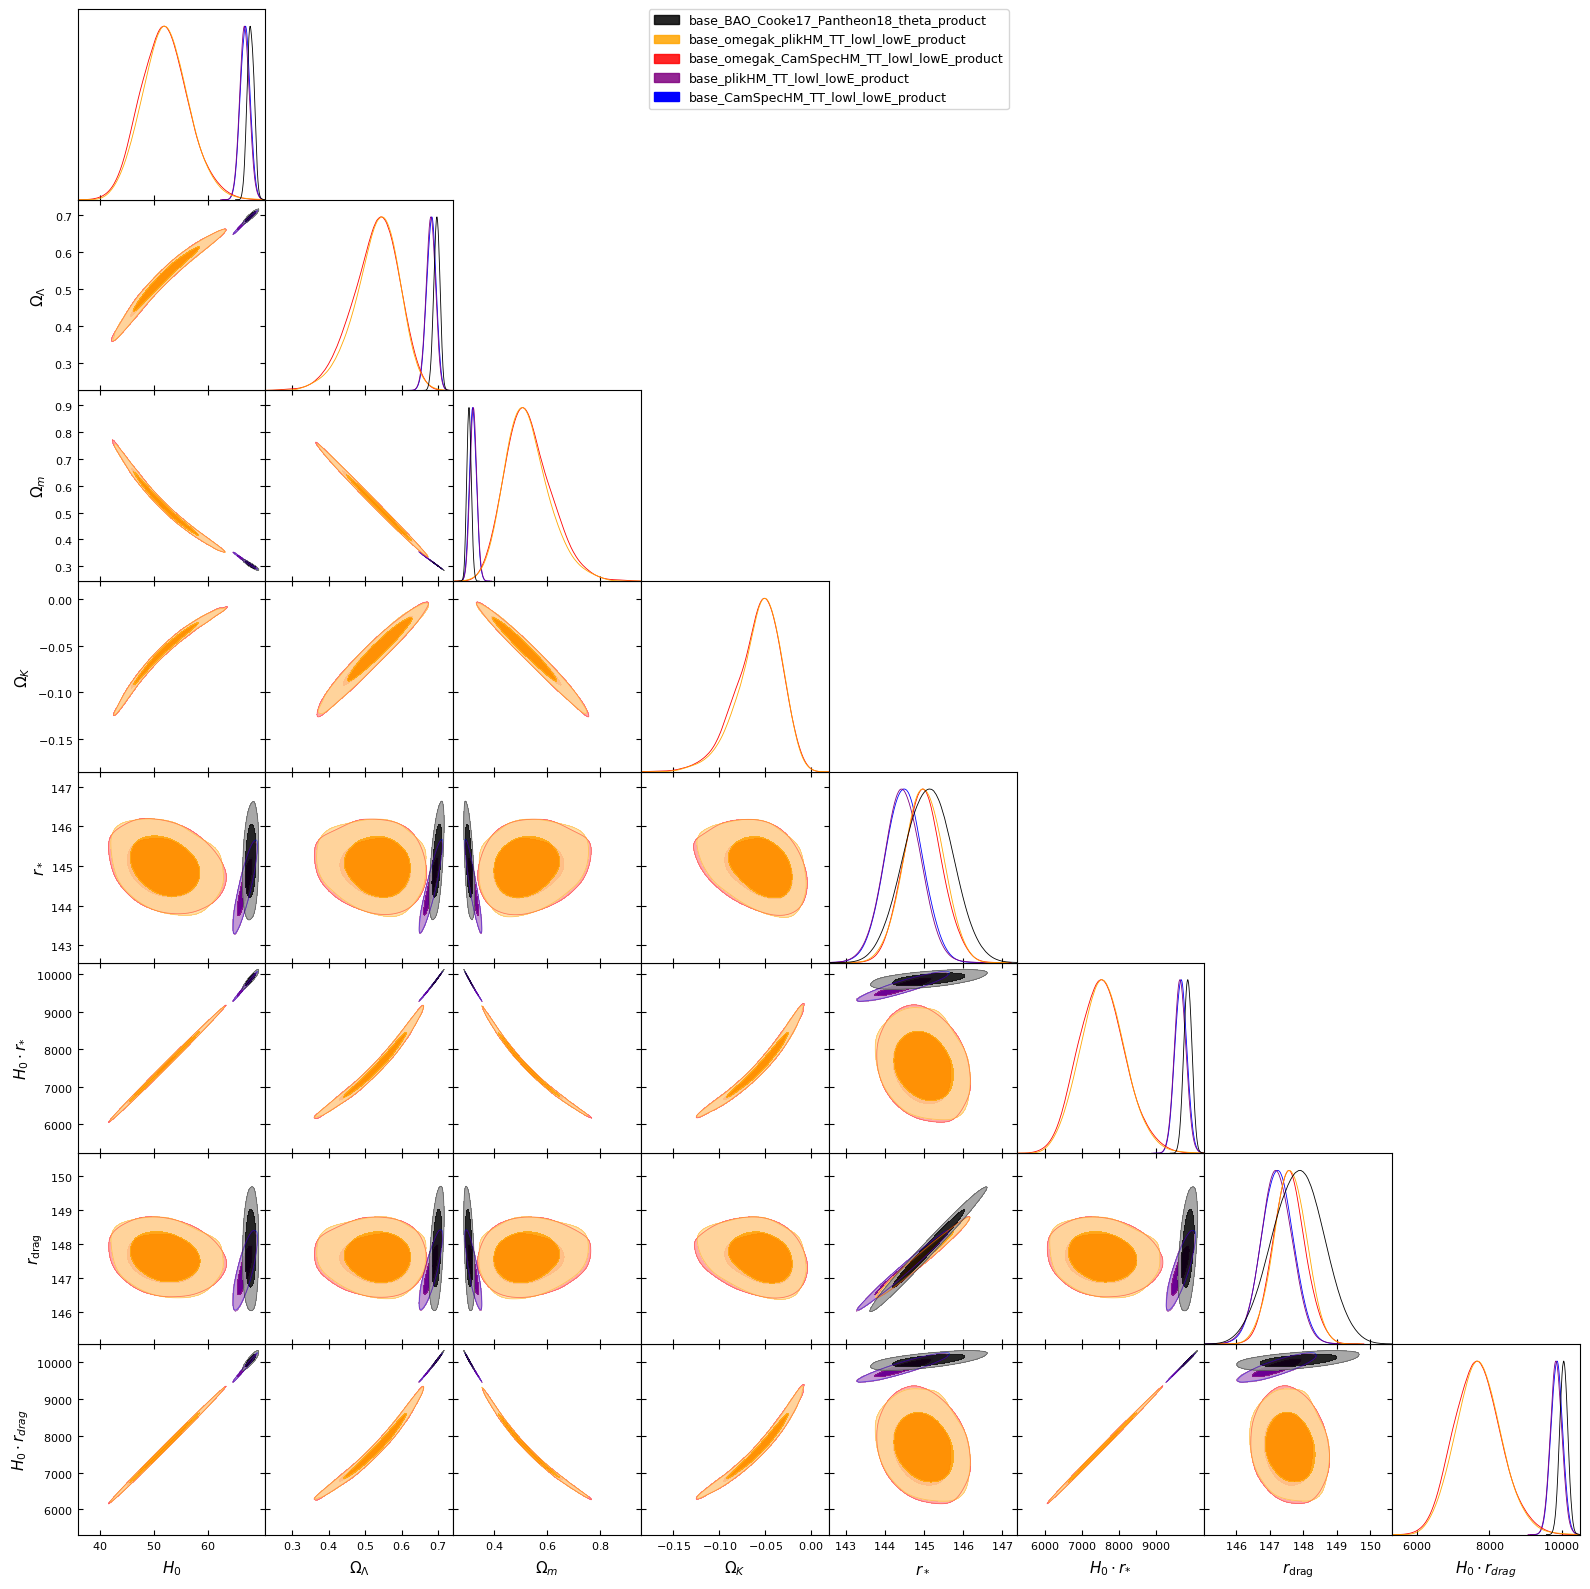

In [1]:
from getdist import plots, loadMCSamples

# Define the roots and the parameters
roots_norm_bao = [
    'COM_CosmoParams_fullGrid_R3.01/base/CamSpecHM_TE_lowE_BAO/base_CamSpecHM_TE_lowE_BAO',
    'COM_CosmoParams_fullGrid_R3.01/base/plikHM_TE_lowE_BAO/base_plikHM_TE_lowE_BAO',
    'COM_CosmoParams_fullGrid_R3.01/base_omegak/CamSpecHM_TT_lowl_lowE_BAO/base_omegak_CamSpecHM_TT_lowl_lowE_BAO',
    'COM_CosmoParams_fullGrid_R3.01/base_omegak/plikHM_TT_lowl_lowE_BAO/base_omegak_plikHM_TT_lowl_lowE_BAO'
]
roots_norm = [
    'COM_CosmoParams_fullGrid_R3.01/base/CamSpecHM_TT_lowl_lowE/base_CamSpecHM_TT_lowl_lowE',
    'COM_CosmoParams_fullGrid_R3.01/base/plikHM_TT_lowl_lowE/base_plikHM_TT_lowl_lowE',
    'COM_CosmoParams_fullGrid_R3.01/base_omegak/CamSpecHM_TT_lowl_lowE/base_omegak_CamSpecHM_TT_lowl_lowE',
    'COM_CosmoParams_fullGrid_R3.01/base_omegak/plikHM_TT_lowl_lowE/base_omegak_plikHM_TT_lowl_lowE'
]
root_bao = 'COM_CosmoParams_fullGrid_R3.01/base/BAO_Cooke17_Pantheon18_theta/base_BAO_Cooke17_Pantheon18_theta'

# Set up the subplot plotter with the correct chain directory
g = plots.get_subplot_plotter(chain_dir='/home/alvar/Research/Cosmo/COM_CosmoParams_fullGrid_R3.01')

# Collect all roots
roots = []
for i in roots_norm:
    roots.append(i) 
roots.append(root_bao)
new_roots = []  # Store products including path

# Loop through each root and compute derived parameters
for root in roots:
    # Load the MCSamples for each root
    samples = loadMCSamples(file_root=root)

    # Access the parameters you want and check they exist
    params_data = samples.getParams()
    if hasattr(params_data, 'H0') and hasattr(params_data, 'rstar') and hasattr(params_data, 'rdrag'):
        # Access and compute the required derived parameters
        H0 = params_data.H0
        rstar = params_data.rstar
        rdrag = params_data.rdrag

        # Calculate the needed products
        product1 = H0 * rstar
        product2 = H0 * rdrag

        # Add new derived parameters
        samples.addDerived(product1, name='H0_times_rs', label='H_0 \\cdot r_{*}')
        samples.addDerived(product2, name='H0_times_rd', label='H_0 \\cdot r_{drag}')

        # Re-save the samples with new derived parameters
        saved_root = samples.saveAsText(root+'_product')
        new_roots.append(saved_root)
    else:
        print(f"Missing parameters in root: {root}")

# Define parameters to include in plot
params = ['H0', 'omegal', 'omegam', 'omegak', 'rstar', 'H0_times_rs', 'rdrag', 'H0_times_rd']

# Execute the triangle plot
roots1_norm_bao = ['base_CamSpecHM_TE_lowE_BAO_product','base_plikHM_TE_lowE_BAO_product',
         'base_omegak_CamSpecHM_TT_lowl_lowE_BAO_product','base_omegak_plikHM_TT_lowl_lowE_BAO_product']

roots1_norm = ['base_CamSpecHM_TT_lowl_lowE_product','base_plikHM_TT_lowl_lowE_product',
         'base_omegak_CamSpecHM_TT_lowl_lowE_product','base_omegak_plikHM_TT_lowl_lowE_product']
roots1_bao = 'base_BAO_Cooke17_Pantheon18_theta_product'
roots3= []
for i,j in zip(roots1_norm, roots1_norm_bao):
    roots3.append(i)
    #roots3.append(j)
roots3.append(roots1_bao)
try:
    g.triangle_plot(roots3, params, filled=True, label_order=-1,contour_colors=['blue','purple', 'red', 'orange', 'black'])
    # Export the plot to a file
    g.export(fname="Base_VS_OMK_VS_BAO_PR3_product.png")
except Exception as e:
    print(f"Failed to plot. Reason: {e}")

In [ ]:
a=plots.get_subplot_plotter(chain_dir=r'/root/Research/Yago/maps/COM_CosmoParams_fullGrid_R3.01')
roots = ['base_CamSpecHM_TT', 'base_omegak_CamSpecHM_TT_lowl_lowE','base_omegak_plikHM_TT_lowl_lowE']
params =  ['H0', 'omegal', 'omegam', 'omegamh2', 'omegamh3', 'chi2_CamSpec', 'chi2_prior']
a.plots_2d(roots, param_pairs=[['omegam', 'omegamh2'], ['omegam', 'omegamh3'], ['omegamh2', 'omegamh3']], filled=True, label_order=-1, contour_colors=['blue', 'green', 'orange'], nx=2)


In [ ]:
from getdist import plots, MCSamples

# Define the roots and the parameters
roots = ['COM_CosmoParams_fullGrid_R3.01/base/BAO_Cooke17_Pantheon18/base_BAO_Cooke17_Pantheon18']
g = plots.get_subplot_plotter(chain_dir='/home/alvar/Research/Cosmo/COM_CosmoParams_fullGrid_R3.01')

# Initialize a list to store modified roots
new_roots = []

# Loop through each root
for root in roots:
    # Load the MCSamples for each root
    samples = loadMCSamples(file_root=root)
    print(samples.getParams().H0)
    print(samples.getParams().rdrag)
    print(samples.getTable(include_bestfit=True,limit=1).tableTex(document=True))
    print("\n")
    print(samples.getTable(include_bestfit=True,limit=2).tableTex(document=True))

In [ ]:
from getdist.mcsamples import loadMCSamples
import camb
import matplotlib.pyplot as plt
import numpy as np

samps = loadMCSamples("hlpTT_lowT/hlpTT_lowT/hlpTT_lowT", 
                       settings = {'ignore_rows':0.3})
samps.thin(20)
n=samps.numrows
print(n)
params_to_keep = {"omegabh2", "omegach2", "H0", "tau", "omegak", "logA", "ns", 
                    "mnu", "w", "wa", "nnu", "yhe", "Alens", "nrun"}
for i in range(2): #omk=dic['omegak'], YHe=dic['yheused']
    dic = samps.getParamSampleDict(i)
    dic['H0'] = None
    dic['thetastar'] = None
    del dic['Aradio']
    del dic['AdustT']
    del dic['cal143A']
    del dic['omegach2']
    del dic['chi2']
    del dic['pe100B']
    del dic['minuslogprior__0']
    #dic['chi2__planck_2020_hillipop']=dic['chi2__planck_2020_hillipop.TT']
    print(dic)
    pars = camb.set_params(**dic)
    res = camb.get_background(pars, no_thermo=True)
    resu = camb.get_results(pars)
    cls = resu.get_cmb_power_spectra(pars, CMB_unit='muK',lmax=2508)
    total_cl = cls['total']
    
    

    ell = unbin_cl['ell']
    D_ell = unbin_cl['D_ell']
    errors = (unbin_cl['-dD_ell'],unbin_cl['+dD_ell'])

    # Create a figure and grid for subplots
    fig, (ax1, ax2) = plt.subplots(2, 1, sharex=True, gridspec_kw={'height_ratios': [3, 1]})
    fig.subplots_adjust(hspace=0)
    fig.set_size_inches(15,10)
    # Top subplot
    ax1.errorbar(ell, D_ell, yerr=errors, fmt='o', color='red', ecolor='blue', elinewidth=1, capsize=2, markersize=2)
    ax1.scatter(ell, total_cl[:,0][2:])
    ax1.set_ylabel('$D_\ell^{TT} \, [\mu K^2]$')
    ax1.grid(True, which='both', linestyle='--', linewidth=0.5)

    # Bottom subplot (Residuals)
    delta_D_ell = np.array(D_ell[:-1]) - np.array(D_ell[1:])

    #ax2.errorbar(ell, delta_D_ell, yerr=errors, fmt='o', color='red', ecolor='blue', elinewidth=1, capsize=2, markersize=2)
    ax2.set_ylabel('$\Delta D_\ell^{TT}$')
    ax2.set_xlabel('$\ell$')
    ax2.grid(True, which='both', linestyle='--', linewidth=0.5)
    ax1.title.set_text("Power Spectrum of TT from Planck Archive Unbinned")
    ax1.axvline(x=20, color='black', linestyle='--', linewidth=0.5)
    ax2.axvline(x=20, color='black', linestyle='--', linewidth=0.5)
    # Show plot
    plt.xscale('log')
    plt.yscale('linear')
    plt.show()

In [9]:
from getdist import loadMCSamples
import numpy as np

# Load the MCSamples for your chain
samples = loadMCSamples(file_root='COM_CosmoParams_fullGrid_R3.01/base_omegak/CamSpecHM_TT_lowl_lowE/base_omegak_CamSpecHM_TT_lowl_lowE')

# Extract chi2 parameters from the samples
chi2_simall = samples.getParams().chi2_simall
chi2_lowl = samples.getParams().chi2_lowl
chi2_CamSpec = samples.getParams().chi2_CamSpec
chi2_prior = samples.getParams().chi2_prior
chi2_CMB = samples.getParams().chi2_CMB

chi2_tot = chi2_simall+chi2_CamSpec+chi2_CMB

# List of parameter names (edit this list according to your chain)
parameter_names = ['H0', 'omegam', 'omegal', 'omegak', 'tau', 'logA', 'ns']

# Function to extract parameter values at the minimum chi2 index for a given chi2 component
def get_best_fit_params_for_chi2(chi2, param_names, params_obj):
    index = np.argmin(chi2)
    return {param: getattr(params_obj, param)[index] for param in param_names}

# Get dictionaries of best-fit parameters for each chi2 component
best_params_chi2_simall = get_best_fit_params_for_chi2(chi2_simall, parameter_names, samples.getParams())
best_params_chi2_lowl = get_best_fit_params_for_chi2(chi2_lowl, parameter_names, samples.getParams())
best_params_chi2_CamSpec = get_best_fit_params_for_chi2(chi2_CamSpec, parameter_names, samples.getParams())
best_params_chi2_prior = get_best_fit_params_for_chi2(chi2_prior, parameter_names, samples.getParams())
best_params_chi2_CMB = get_best_fit_params_for_chi2(chi2_CMB, parameter_names, samples.getParams())
best_params_chi2_tot = get_best_fit_params_for_chi2(chi2_tot, parameter_names, samples.getParams())

# Print the best-fit parameters for each chi2 component
print(f"Best fit parameters based on minimum chi2_simall: {min(chi2_simall)}")
print(best_params_chi2_simall)

print(f"\nBest fit parameters based on minimum chi2_lowl: {min(chi2_lowl)}")
print(best_params_chi2_lowl)

print(f"\nBest fit parameters based on minimum chi2_CamSpec: {min(chi2_CamSpec)}")
print(best_params_chi2_CamSpec)

print(f"\nBest fit parameters based on minimum chi2_prior: {min(chi2_prior)}")
print(best_params_chi2_prior)

print(f"\nBest fit parameters based on minimum chi2_CMB: {min(chi2_CMB)}")
print(best_params_chi2_CMB)
print(f"\nBest fit parameters based on minimum chi2_tot: {min(chi2_tot)/2}")
print(best_params_chi2_tot)

Best fit parameters based on minimum chi2_simall: 395.4129
{'H0': np.float64(42.55737), 'omegam': np.float64(0.7480833), 'omegal': np.float64(0.3854581), 'omegak': np.float64(-0.1335415), 'tau': np.float64(0.05125829), 'logA': np.float64(3.014438), 'ns': np.float64(0.9883614)}

Best fit parameters based on minimum chi2_lowl: 20.08074
{'H0': np.float64(60.19775), 'omegam': np.float64(0.3800459), 'omegal': np.float64(0.6438689), 'omegak': np.float64(-0.02391477), 'tau': np.float64(0.06655806), 'logA': np.float64(3.057765), 'ns': np.float64(0.9875173)}

Best fit parameters based on minimum chi2_CamSpec: 7046.235
{'H0': np.float64(56.01196), 'omegam': np.float64(0.4532292), 'omegal': np.float64(0.5807451), 'omegak': np.float64(-0.03397435), 'tau': np.float64(0.04967383), 'logA': np.float64(3.028849), 'ns': np.float64(0.9693211)}

Best fit parameters based on minimum chi2_prior: 0.6508498
{'H0': np.float64(48.22876), 'omegam': np.float64(0.6016926), 'omegal': np.float64(0.4775772), 'omegak'